# 🏏 IPL Tweet Sentiment Analysis (2020–2022) Using PySpark + VADER


# Load Spark + VADER

In [1]:
import os
import sys

os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] += os.pathsep + "C:\\hadoop\\bin"

# Set python executable path
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.sql.types import StringType
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [3]:
spark = SparkSession.builder.appName("IPL Sentiment Notebook").getOrCreate()

In [4]:
spark

# Load 2020,2021,2022 Dataset → Drop extra cols and merging them using union by

In [5]:
df_2020 = spark.read.csv("IPL2020_Tweets.csv", header = True, inferSchema = True)
df_2020 = df_2020.drop("month", "year").filter(col("text").isNotNull())

df_2021 = spark.read.csv("IPL_2021_tweets.csv", header = True, inferSchema = True)
df_2021 = df_2021.filter(col("text").isNotNull())

df_2022 = spark.read.csv("IPL_2022_tweets.csv", header = True, inferSchema = True)
df_2022 = df_2022.filter(col("text").isNotNull())

df_all = df_2020.unionByName(df_2021).unionByName(df_2022)
df_all = df_all.select("text")  # Optional: only keep relevant

# ✅ VADER UDF Setup

In [8]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

sentiment_udf = udf(get_sentiment, StringType())

df_scored = df_all.withColumn("sentiment", sentiment_udf(col("text")))
df_scored.show(20)

+--------------------+---------+
|                text|sentiment|
+--------------------+---------+
|Time to change th...|  neutral|
|@ICC And still #r...|  neutral|
|     Twitter Web App|  neutral|
|           #IPL2020 |  neutral|
|           #IPL2020 |  neutral|
|After #IPL2020  P...| positive|
| Twitter for Android|  neutral|
|“If they are not ...| negative|
|The man behind al...|  neutral|
|🎧 IPL Cricket Sh...|  neutral|
|Congratulations R...| positive|
| #IPL2020 playing11 |  neutral|
|@MahelaJay 🤔Noti...|  neutral|
|#INDvsAUS #AUSvsI...|  neutral|
|Jos Buttler prefe...|  neutral|
|IPL 2020: How fiv...| positive|
|       Back Win Bets| positive|
|The best all roun...| positive|
|Top 40 batsmen an...| positive|
|.@nassercricket p...|  neutral|
+--------------------+---------+
only showing top 20 rows



# Saving score File

In [9]:
df_pd = df_scored.toPandas()
df_pd.to_csv("ipl_sentiment_final.csv", index=False)

# Visualizations

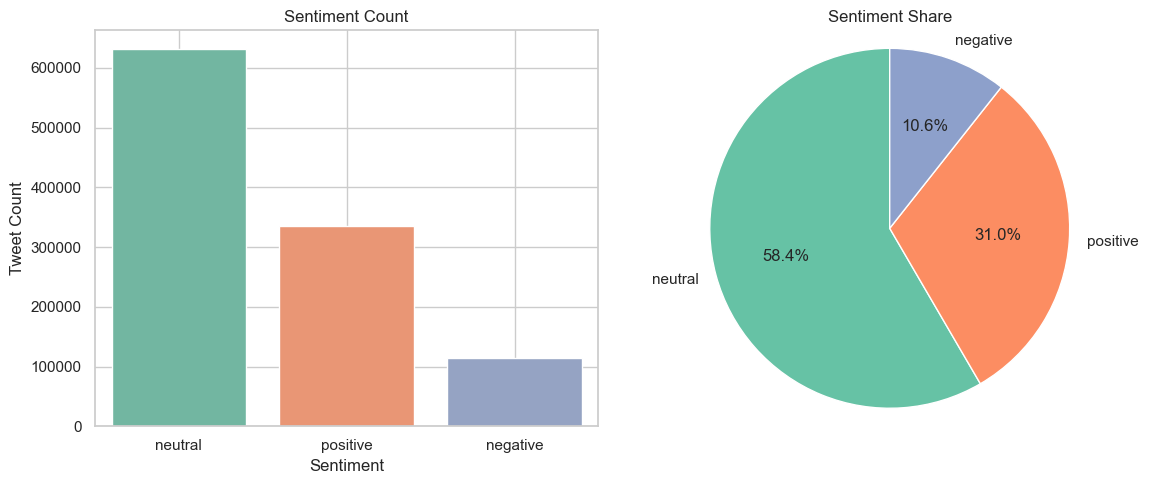

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your cleaned sentiment CSV
df = pd.read_csv("ipl_sentiment_final.csv")  # Replace with actual file

# Count sentiment distribution
sentiment_counts = df['sentiment'].value_counts()

# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# Subplot 1: Bar Chart
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="sentiment", hue="sentiment", palette="Set2", legend=False)
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.grid(True)

# Subplot 2: Pie Chart
plt.subplot(1, 2, 2)
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2")
)
plt.title("Sentiment Share")
plt.axis("equal")

plt.tight_layout()
plt.show()
